# 概要

動物の鳴き声(牛、熊)のデータセットを利用する<br>
3層のSAMACTが牛の鳴き声を学習してオートエンコーダを構築し、<br>
牛の鳴き声に対しては低い異常度を、熊の鳴き声に対しては高い異常度を出力するシナリオ。

実行時間: 1分程度

1. データの準備(前処理含む)
2. ニューラルネットワークの構築<br>
  2-1. エンコーダの設定<br>
  2-2. SAMレイヤーの設定<br>
  2-3. デコーダの設定<br>
  2-4. ニューラルネットワークの生成
3. 学習<br>
  3-1. 学習プロパティの設定<br>
  3-2. 学習の実施<br>
  3-3. 学習結果の保存
4. 推論<br>
  4-1. テスト用データセットをまとめて推論<br>
  4-2. 1データを推論


## 注意
本シナリオでは、追加で下記のライブラリを必要とする。
- librosa
- pandas

# 1. データの準備(前処理含む)
今回、前処理にメルスペクトログラムを利用。

In [1]:
from pathlib import Path

import numpy as np
import librosa

# 前処理とmainで共通して利用する変数
N_FEATURES = 25 # 説明変数の数

# 前処理で正規化するときに使う範囲。(全次元共通)
# 個別に情報量最大になる範囲を設定すると、より良い結果を得られる。
MIN_MEL = -50
MAX_MEL = 0

def MakePreProcessedDataset(basePath:Path)->tuple[np.ndarray, np.ndarray]:
    """
    data, labelを返す。
    この返り値をSAMACTに渡せばよい。
    """

    dataset = []
    labels = []

    # 探索順の再現性のためにsortedを使用(iでラベルを貼るため)
    # 各種wavファイルのmelspectrogramを計算し、正常/異常のラベルを貼って、行列としてまとめる。
    for i, labelDirPath in enumerate(sorted(basePath.glob("*/"))):
        datasetOnLabel = []

        # ファイルの順番の再現性のためにsortedを使用
        for wav in sorted(labelDirPath.glob("*.wav")):
            y, sr = librosa.load(path=wav, sr=None)
            melSpec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_FEATURES,
                                                     n_fft=2048, hop_length=256)
            melSpecDb = librosa.power_to_db(melSpec, ref=1.0,
                                            amin=1e-10, top_db=80.0)
            # librosaの返り値は想定する行列と、軸が逆なので転置してスケーリング
            normMelSpecDb = (melSpecDb.T - MIN_MEL) / (MAX_MEL - MIN_MEL)

            datasetOnLabel.append(normMelSpecDb)

        naDatasetOnLabel = np.vstack(datasetOnLabel)
        dataset.append(naDatasetOnLabel)

        labels.extend([i]*len(naDatasetOnLabel))

    # SAMACTは内部的にオンライン学習するため、ラベルの偏りが悪影響を与える。
    # シャッフルすることで対策する。
    naDataset = np.vstack(dataset)
    naLabels = np.array(labels)
    np.random.seed(0)
    indice = np.arange(len(naDataset))
    np.random.shuffle(indice)
    datasetShuffled = naDataset[indice, :]
    labelShuffled = naLabels[indice]

    return datasetShuffled, labelShuffled

In [2]:
trainPath = Path("data/AnimalCry/train")
testPath = Path("data/AnimalCry/test")

list(trainPath.glob('*/*.wav')), list(testPath.glob('*/*.wav'))

([PosixPath('data/AnimalCry/train/0_normal/cow_1.wav'),
  PosixPath('data/AnimalCry/train/0_normal/cow_2.wav'),
  PosixPath('data/AnimalCry/train/1_anomaly/bear_1.wav'),
  PosixPath('data/AnimalCry/train/1_anomaly/bear_2.wav'),
  PosixPath('data/AnimalCry/train/1_anomaly/bear_3.wav'),
  PosixPath('data/AnimalCry/train/1_anomaly/bear_4.wav')],
 [PosixPath('data/AnimalCry/test/0_normal/cow_3.wav'),
  PosixPath('data/AnimalCry/test/1_anomaly/bear_5.wav')])

In [3]:
trainData, trainLabel = MakePreProcessedDataset(trainPath)
testData, testLabel = MakePreProcessedDataset(testPath)
trainData.shape, trainLabel.shape

((1356, 25), (1356,))

## 数値について
特徴量の数値は、フレームワーク内部で下記のように丸められる。
- 0未満の数値 → 0
- 1より大きい数値 → 1

そのため、本サンプルの正規化部分ではclipを省略している。

In [4]:
# dataをprintすると、負の数も見られるが上記の仕様によりフレームワーク内部では0とみなされる
trainData, trainLabel

(array([[ 0.6293874 ,  1.2492273 ,  1.3387028 , ..., -0.2116063 ,
         -0.2116063 , -0.2116063 ],
        [ 0.7305244 ,  1.230959  ,  1.2643216 , ..., -0.12197777,
         -0.12197777, -0.12197777],
        [ 0.6800262 ,  1.0338962 ,  1.2426364 , ..., -0.207816  ,
         -0.207816  , -0.207816  ],
        ...,
        [ 0.5162327 ,  0.8658459 ,  0.9948055 , ..., -0.20839158,
         -0.20839158, -0.20839158],
        [ 0.77948385,  1.0385212 ,  1.1599823 , ..., -0.12197777,
         -0.12197777, -0.12197777],
        [ 0.66263497,  1.2824502 ,  1.3265332 , ..., -0.12197777,
         -0.12197777, -0.12197777]], dtype=float32),
 array([1, 0, 1, ..., 1, 0, 0]))

## ラベル
本シナリオはオートエンコーダとしてのSAMACT利用を想定しているため、ラベルは入力不要。
学習用の正常データの抽出と、得られたモデルの評価のためにのみ、ラベルを利用する。

# 正常データを抽出
学習データセットから、正常ラベルが貼られたデータのみを抽出する。<br>
正常データのみしか潤沢に得られない、という想定のもとでオートエンコーダを利用するため。

In [5]:
normalTrainIndice = np.where(trainLabel == 0)
normalTrainData = trainData[normalTrainIndice]
normalTrainData.shape

(822, 25)

# 2. ニューラルネットワークの構築
SAMACTのフレームワークの各要素をインスタンスして、ニューラルネットワークを構築する。

本サンプルシナリオでは、3層(100-50-100)のニューラルネットワーク(オートエンコーダ)を構築する。

In [6]:
from samact import *

## 2-1. エンコーダの設定
エンコーダとして、RateEncodeLayerを指定。<br>
パラメータnUnitsは入力する特徴量の数と一致させる。

In [7]:
N_NEURON_PER_VAR = 4

inputLayer = NeuronFocusEncodeLayer(N_FEATURES, N_NEURON_PER_VAR)
inputLayer

NeuronFocusEncode(nUnits=25, nNeuronPerExpVar=4)

## 2-2. SAMレイヤーの設定(隠れ層)

隠れ層として、SAMLayerを指定。

In [8]:
hiddenLayer = SAMLayer(50, LayerProperty(a=3, p=0.75), Step(), Step(),
                       weightDist=RandomProperty('kaiming', 'normal'))
hiddenLayer

SAMLayer(nUnits=50, gradAct=Step(a=0, b=6, g=18), teacherAct=Step(a=0, b=6, g=18))

## 2-2. SAMレイヤーの設定(出力層)
出力層として、SAMLayerを指定。<br>
パラメータnUnitsは分類するカテゴリ数と一致させる。

In [9]:
outputLayer = SAMLayer(N_FEATURES*N_NEURON_PER_VAR, LayerProperty(a=3, p=0.75), Step(), Linear(),
                       weightDist=RandomProperty('kaiming', 'normal'))
outputLayer

SAMLayer(nUnits=100, gradAct=Step(a=0, b=6, g=18), teacherAct=Linear(nSlopeLeftShifts=0))

## 2-3. デコーダの設定

デコーダとして、AutoEncoderDecodeLayerを定義。<br>
SAMACTをオートエンコーダとして扱いたい場合、このデコーダを指定する。

In [10]:
decoder = AutoEncoderDecodeLayer()
decoder

AutoEncoderDecode

## 2-4. ネットワークの設定
Sequentialモデルとして、SAMACTのネットワークを定義。

In [11]:
model = Sequential(inputLayer, decoder, [hiddenLayer, outputLayer])
model.Compile(32)
model

Model summary
  Encoder: NeuronFocusEncode(nUnits=25, nNeuronPerExpVar=4)
  Layers:
    [0] SAMLayer(nUnits=50, gradAct=Step(a=0, b=6, g=18), teacherAct=Step(a=0, b=6, g=18))
    [1] SAMLayer(nUnits=100, gradAct=Step(a=0, b=6, g=18), teacherAct=Linear(nSlopeLeftShifts=0))
  Decoder: AutoEncoderDecode
  tC: 32

# 3. 学習
学習用のデータセットを利用して、SAMACTを学習させる。

## 3-1. 学習プロパティの設定
学習の際のパラメータを設定する。

In [12]:
learnProperty = LearningProperty(eta=5, iota=2, decayPeriod=1)

## 3-2. 学習の実施
フレームワークのFitメソッドを利用してモデルを学習させる。

In [13]:
fitResult = model.Fit(normalTrainData, None, 6, learnProperty, metrics='mse')

In [14]:
# エポックごとの学習精度
fitResult.metrics

[0.005650590218046829,
 0.001546865497583788,
 0.000994204779495094,
 0.0005209164962214629,
 0.00037474100977885757,
 0.00035246540478185587]

## 3-3. 学習結果の保存
学習結果(学習可能パラメータ)をnpzファイルとして保存する。

In [15]:
model.Save('fitResultSample.h5')

In [16]:
normalTestIndice = np.where(testLabel == 0)
anomalyTestIndice = np.where(testLabel != 0)
normalTestData = testData[normalTestIndice]
anomalyTestData = testData[anomalyTestIndice]

# 4. 推論
SAMACTモデルにデータセットを推論させる。

## 4-1. テスト用データセットをまとめて推論
事前にテスト用に温存していたデータセットをSAMACTに推論させる。<br>
学習に成功していれば、正常データを入力した場合に低い異常度が出力され、<br>
異常データを入力した場合に、高い異常度が出力される。

In [17]:
evalResultNormal = model.Evaluate(normalTestData, None, 'mse')
evalResultNormal.metrics

0.0003347054553789731

In [18]:
evalResultAnomaly = model.Evaluate(anomalyTestData, None, 'mse')
evalResultAnomaly.metrics

0.021845115718984964

# (参考)推論結果のグラフ描画
正常データを入力したときにSAMACTが出力する異常度と、<br>
異常データを入力したときにSAMACTが出力する異常度は、<br>
下記のような箱ひげ図、折れ線グラフで示されます。(可視化手法は一例)

<Axes: title={'center': 'Comparation between normal and anomaly'}, ylabel='anomaly score(MSE)'>

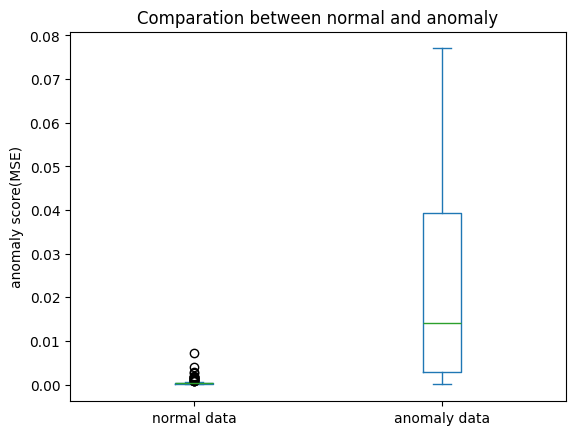

In [19]:
import pandas as pd
dfNormalResult = pd.DataFrame(evalResultNormal.predicts, columns=['normal data'])
dfAnomalyResult = pd.DataFrame(evalResultAnomaly.predicts, columns=['anomaly data'])

dfCombinedResult = pd.concat([dfNormalResult, dfAnomalyResult])
dfCombinedResult.plot.box(ylabel='anomaly score(MSE)', title='Comparation between normal and anomaly')

<Axes: title={'center': 'Comparation between normal and anomaly'}, xlabel='time[record]', ylabel='anomaly score(MSE)'>

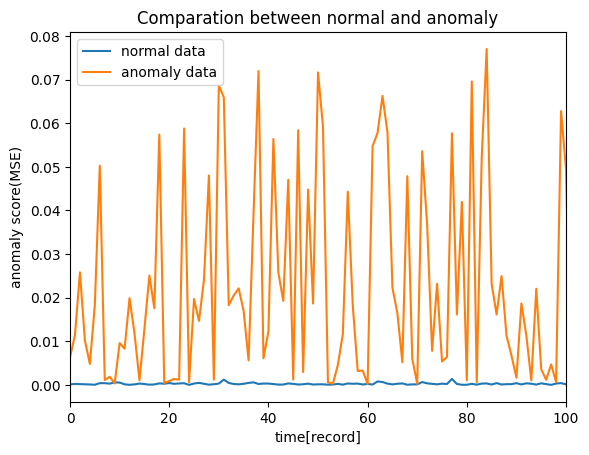

In [20]:
dfCombinedResult.plot(title='Comparation between normal and anomaly', xlim=[0, 100],
                      xlabel='time[record]', ylabel='anomaly score(MSE)')